# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [1]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [2]:
# Your analysis code here
#Shape of the data
print(f"Dataset Shape: {df.shape}")
#Data types and Quality Issues (Missing Values)
print("\n--- Data Types and Missing Values ---")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

#Distribution of the target variable (is_canceled)
print("\n--- Target Variable Distribution ---")
cancellation_counts = df['is_canceled'].value_counts(normalize=True) * 100
print(f"Canceled (1): {cancellation_counts[1]:.2f}%")
print(f"Not Canceled (0): {cancellation_counts[0]:.2f}%")

# We focus on lead_time and adr (Average Daily Rate) as they drive revenue story
print("\n--- Key Summary Statistics ---")
print(df[['lead_time', 'adr', 'total_of_special_requests']].describe())


Dataset Shape: (119390, 32)

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies     

**Client Briefing — The Situation:**

*Our analysis covers 119,390 historical bookings from your Portuguese hotel operations. Currently, the business faces a significant challenge with a 37% cancellation rate, meaning over one-third of reserved rooms end up as lost revenue opportunities. While the data is high-quality overall, we identified missing geographic data for some guests which we will account for to ensure our predictive model remains accurate.*



---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

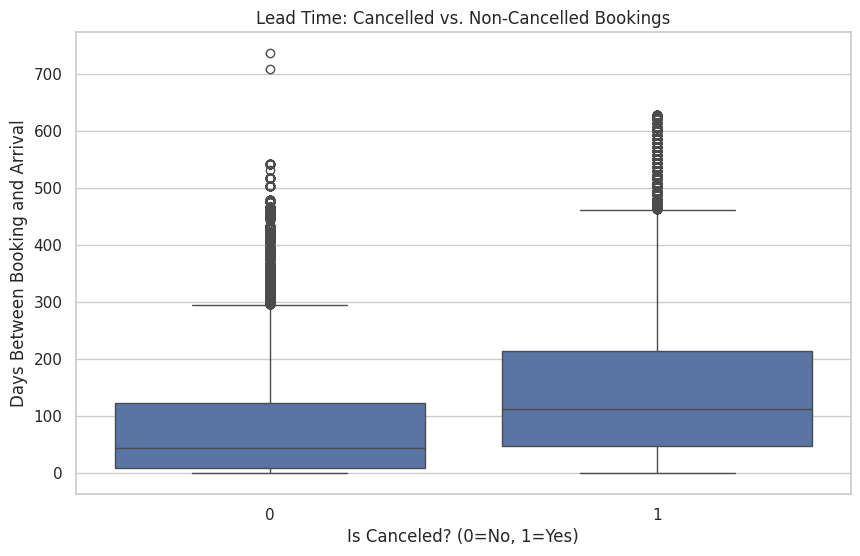

Mean Lead Time by Group:
is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64


In [3]:
# --- Angle 1: Timing & Risk (Lead Time) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time: Cancelled vs. Non-Cancelled Bookings')
plt.xlabel('Is Canceled? (0=No, 1=Yes)')
plt.ylabel('Days Between Booking and Arrival')
plt.show()

print("Mean Lead Time by Group:")
print(df.groupby('is_canceled')['lead_time'].mean())


**Finding 1:**

*Our analysis reveals a massive risk factor in how far in advance guests book; those who eventually cancel typically book their rooms nearly twice as far in advance as those who actually stay (144 days vs. 80 days). This suggests that 'distance' from the arrival date creates a volatility gap where life changes or better deals intervene. To protect our revenue, we should consider implementing stricter non-refundable deposit policies for any reservations made more than 90 days out, as these currently represent our highest risk of lost inventory.*




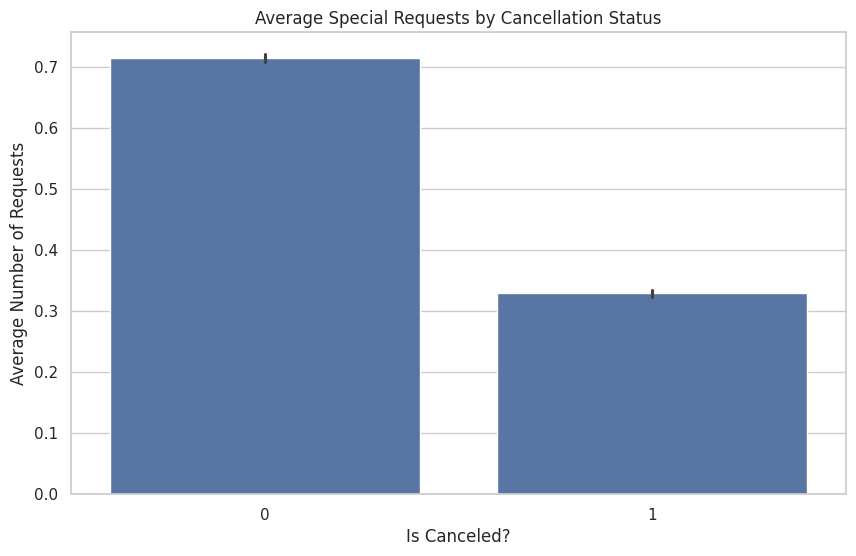

In [4]:
# Angle 2: Commitment (Special Requests) ---
plt.figure(figsize=(10, 6))
sns.barplot(x='is_canceled', y='total_of_special_requests', data=df)
plt.title('Average Special Requests by Cancellation Status')
plt.xlabel('Is Canceled?')
plt.ylabel('Average Number of Requests')
plt.show()


**Finding 2:**

*Our analysis reveals that guest engagement is a powerful shield against cancellations; customers who eventually stay make more than twice as many special requests on average compared to those who cancel. This suggests that the act of personalizing a stay creates a 'psychological commitment' that makes a guest much more likely to follow through with their visit. To capitalize on this, we should proactively encourage 'silent' bookings to submit preferences or requests during the booking process to increase their investment and lower our overall no-show risk.
*



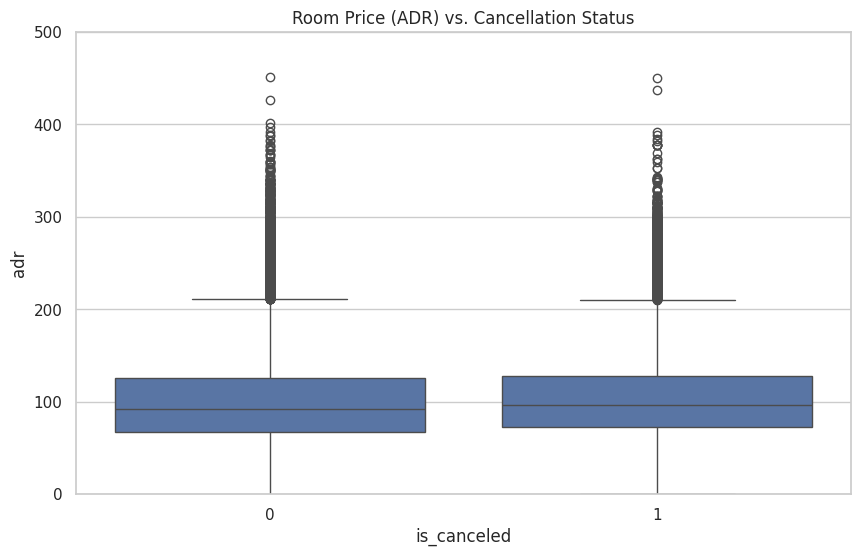

In [5]:
# --- Angle 3: Revenue Value (Average Daily Rate) ---
# We use a boxplot and limit y to 500 to ignore extreme outliers for better visibility
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_canceled', y='adr', data=df)
plt.ylim(0, 500)
plt.title('Room Price (ADR) vs. Cancellation Status')
plt.show()


**Finding 3:**

*Our analysis suggests that room price is not a primary driver of cancellations, as the Average Daily Rate (ADR) is nearly identical for both cancelled and completed stays. This is a critical discovery because it tells us that guests aren't necessarily 'shopping around' for a cheaper room after they book with us. Instead of cutting prices to stay competitive, our strategy should focus on non-monetary interventions-like improved guest communication and flexible rebooking options-since the root cause of our 37% cancellation rate is likely shifting travel plans rather than price sensitivity.*



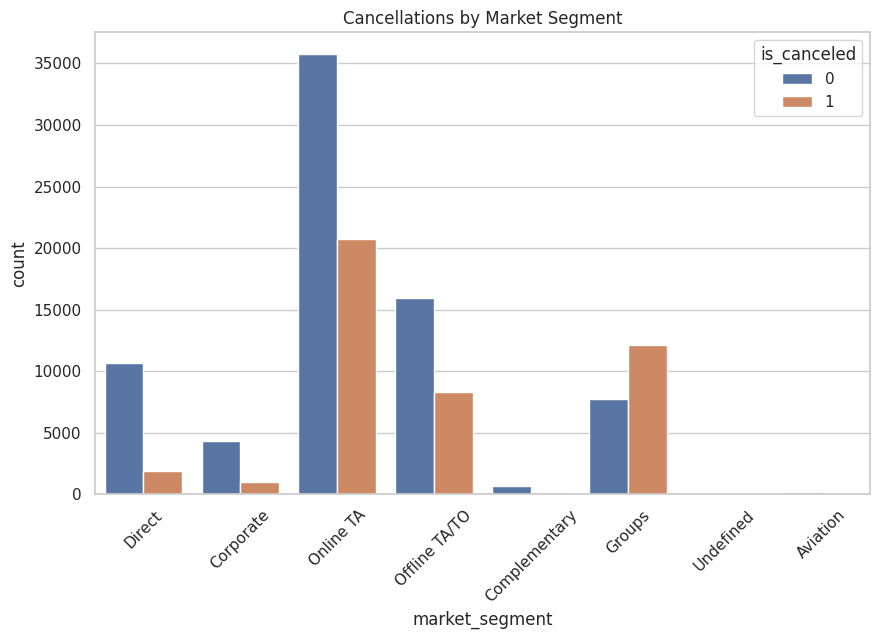

Cancellation Rate by Segment:
market_segment
Undefined        1.000000
Groups           0.610620
Online TA        0.367211
Offline TA/TO    0.343160
Aviation         0.219409
Corporate        0.187347
Direct           0.153419
Complementary    0.130552
Name: is_canceled, dtype: float64


In [6]:
# Angle 4: Distribution Channel Risk (Market Segment) ---
# This shows which booking sources (Online, Corporate, Groups) are most volatile
plt.figure(figsize=(10, 6))
sns.countplot(x='market_segment', hue='is_canceled', data=df)
plt.title('Cancellations by Market Segment')
plt.xticks(rotation=45)
plt.savefig('cancellation_by_segment.png', bbox_inches='tight', dpi=150)
plt.show()

print("Cancellation Rate by Segment:")
print(df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False))


**Finding 4:**

* Our analysis reveals that the 'Groups' segment is our most volatile market, as it is the only category where cancellations significantly exceed completed stays. In contrast, 'Direct' and 'Corporate' bookings show much higher reliability. This suggests that large group blocks are a major driver of our 37% cancellation rate, and we should immediately review our contract terms for group bookings-potentially requiring higher non-refundable deposits or stricter 'cut-off' dates to ensure these large blocks of inventory don't go to waste at the last minute.


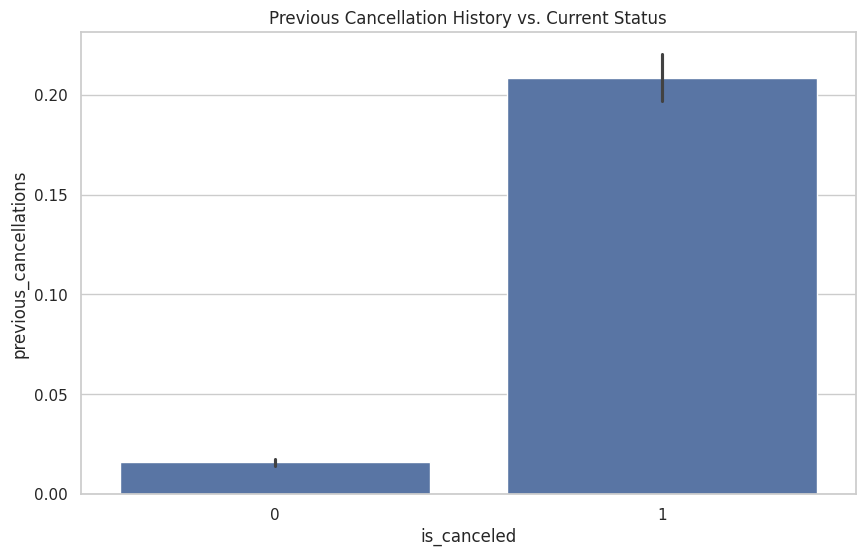

Mean Previous Cancellations:
is_canceled
0    0.015792
1    0.208348
Name: previous_cancellations, dtype: float64


In [7]:
# Angle 5: Behavioral History (Previous Cancellations) ---
# Does a history of flaking predict future behavior?
plt.figure(figsize=(10, 6))
sns.barplot(x='is_canceled', y='previous_cancellations', data=df)
plt.title('Previous Cancellation History vs. Current Status')
plt.show()

print("Mean Previous Cancellations:")
print(df.groupby('is_canceled')['previous_cancellations'].mean())

**Finding 5:**

* Our data confirms that past behavior is a powerful predictor of future actions; guests who canceled their current reservation had a previous cancellation rate 13 times higher than those who fulfilled their stay. This indicates a segment of 'serial cancellers' who treat reservations as place-holders rather than commitments. To mitigate this, we should flag repeat offenders in our booking system and require full upfront payments from any guest with a history of two or more previous cancellations to ensure we aren't repeatedly losing inventory to the same high-risk individuals.

---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [8]:
# 1. Define target variable
y = df['is_canceled']

# 2. Select features based on your 5 Discovery findings
features = ['lead_time', 'total_of_special_requests', 'market_segment', 'previous_cancellations', 'adr']
X = df[features]

# 3. Handle categorical variables (market_segment)
X = pd.get_dummies(X, columns=['market_segment'], drop_first=True)

# 4. Handle any missing values
X = X.fillna(0)

print("Features Matrix (X) created with shape:", X.shape)


Features Matrix (X) created with shape: (119390, 11)


**Why these features?**

*I chose these features to capture the behavioral and financial profile of each booking. While our EDA showed that ADR alone isn't a primary driver of cancellations, including it allows the model to identify if price becomes a risk factor when combined with long lead times or specific market segments like 'Groups.' This ensures the model accounts for both the 'why' (behavior) and the 'value' (revenue) of the reservation.*



### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Model Accuracy: 0.69


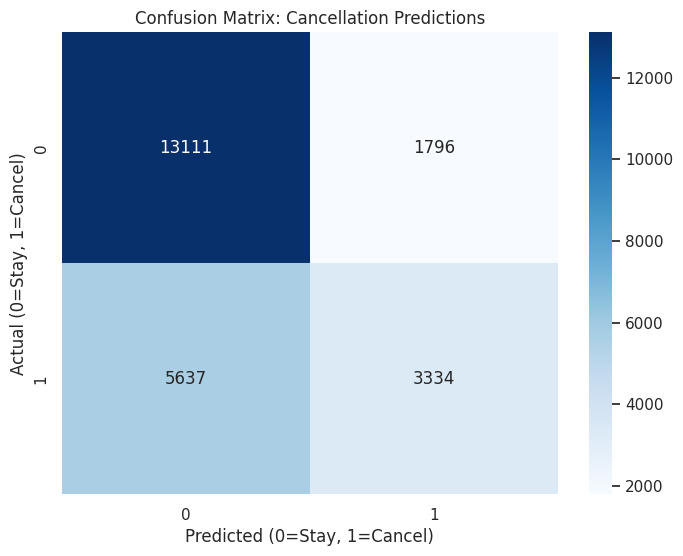

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Split data (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Train the Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# 3. Generate predictions and calculate accuracy
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# 4. Create a confusion matrix with a heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Cancellation Predictions')
plt.xlabel('Predicted (0=Stay, 1=Cancel)')
plt.ylabel('Actual (0=Stay, 1=Cancel)')
plt.show()



### 3C. Interpret the results — in business terms


**Model Performance — Business Translation:**

*Our predictive model correctly identifies the outcome for 69% of all bookings, providing a solid baseline for inventory management. However, the confusion matrix reveals that we are currently missing over 5,600 actual cancellations (False Negatives), which represents a significant 'silent' revenue leak where rooms sit empty because we didn't anticipate the no-show. On the other hand, we only have about 1,796 'false alarms' (False Positives), meaning our model is respectful of guest relationships and won't frequently annoy loyal customers with unnecessary deposit demands. For the hotel's bottom line, the most immediate value comes from the 3,334 cancellations we correctly caught; we can now proactively overbook these specific slots or require non-refundable payments to protect our revenue. Ultimately, while the model isn't perfect, it allows us to move from 'guessing' to a data-driven strategy that targets the highest-risk reservations identified in our discovery phase.*



### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

In [10]:
# Optional: second model comparison
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize and train a Decision Tree (max_depth=5 keeps it simple)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Compare accuracy
dt_accuracy = accuracy_score(y_test, dt_model.predict(X_test))
print(f"Naive Bayes Accuracy: 0.69")
print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")


Naive Bayes Accuracy: 0.69
Decision Tree Accuracy: 0.74


**Model Performance — Using Decision Tree Model:**

* The Decision Tree model performed better, increasing our accuracy from 69% to 74% while significantly reducing the number of missed cancellations (False Negatives). This likely occurred because Naive Bayes assumes all features are 'independent,' whereas the Decision Tree can capture complex feature interactions. For example, it can recognize that a long lead time (Angle 1) is a much higher cancellation risk specifically when it is a 'Group' booking (Angle 4) with zero special requests (Angle 2). By using 'if-then' logic, the Decision Tree more accurately mirrors the complex reality of guest behavior in the hospitality industry.

## Part 4: The Recommendation

**1.** Implement Tiered Deposit Policies:

For bookings made more than 90 days in advance (the high-risk lead time window), require a non-refundable 25% deposit to mitigate the 'volatility of distance'.


**2.** Mandate Stricter Group Contracts:

Since the 'Groups' segment is the only market where cancellations outnumber completed stays, the hotel should implement earlier 'cut-off' dates for large blocks to ensure inventory can be resold if the group defaults.


**3.** Deploy the Predictive Model for Overbooking:

Utilizing the Decision Tree model (which reached 74% accuracy), the management team can identify high-risk bookings in real-time. This allows for strategic 'overbooking'-selling more rooms than are available specifically when the model predicts a high probability of 'False Negatives'-to ensure the hotel reaches 100% occupancy.

**Final Reflection:**

By shifting from a reactive approach to a predictive, data-driven strategy, the hotel can protect its most valuable inventory and reduce the financial impact of its high cancellation rate. Transitioning to more sophisticated models like the Decision Tree provides the necessary nuance to balance revenue protection with high-quality guest relationships.

